# **INSTALLING THE LIBARIES**

In [6]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, RBF
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib.ticker import AutoMinorLocator
from scipy.stats import gaussian_kde
import warnings
import os

In [ ]:
# **The PLOTING FEATURES**

In [7]:


warnings.filterwarnings("ignore")
matplotlib.rcParams['font.family']       = 'DejaVu Sans'
matplotlib.rcParams['axes.linewidth']    = 2.0
matplotlib.rcParams['xtick.major.width'] = 1.8
matplotlib.rcParams['ytick.major.width'] = 1.8
matplotlib.rcParams['xtick.minor.width'] = 1.0
matplotlib.rcParams['ytick.minor.width'] = 1.0
matplotlib.rcParams['xtick.direction']   = 'in'
matplotlib.rcParams['ytick.direction']   = 'in'
matplotlib.rcParams['xtick.major.size']  = 6
matplotlib.rcParams['ytick.major.size']  = 6
matplotlib.rcParams['xtick.minor.size']  = 3
matplotlib.rcParams['ytick.minor.size']  = 3

OUTPUT_DIR        = "spoilage_graphs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CSV_PATH          = "Meat_data_2nd.csv"
SPOILAGE_PH       = 3.2
ALERT_MINUTES     = 60
GA_POP_SIZE       = 20
GA_GENERATIONS    = 25
GA_MUTATION_RATE  = 0.15
GA_CROSSOVER_RATE = 0.7
TSCV_SPLITS       = 5
RANDOM_SEED       = 42
np.random.seed(RANDOM_SEED)

C = dict(
    ph        = "#1f77b4",
    mq135     = "#d62728",
    mq136     = "#2ca02c",
    mq137     = "#9467bd",
    amb_temp  = "#ff7f0e",
    food_temp = "#8c564b",
    humidity  = "#17becf",
    spoilage  = "#e377c2",
    gpr       = "#1f77b4",
    svr       = "#ff7f0e",
    ensemble  = "#2ca02c",
    true_val  = "#d62728",
    alert     = "#d62728",
    safe      = "#2ca02c",
    warning   = "#ff7f0e",
    ga_hist   = "#9467bd",
    ci        = "#1f77b4",
)

ZONE_COLORS = dict(fresh="#2ca02c", warning="#ff7f0e", spoiled="#d62728")

def style_ax(ax, fontsize=14):
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    ax.tick_params(which='major', labelsize=fontsize - 2, width=1.8, length=6)
    ax.tick_params(which='minor', width=1.0, length=3)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.set_xlabel(ax.get_xlabel(), fontsize=fontsize, fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=fontsize, fontweight='bold')
    ax.set_title(ax.get_title(),   fontsize=fontsize + 1, fontweight='bold')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
        lbl.set_fontsize(fontsize - 2)


Spoilage onset: 492.8 min (8.21 hrs)
GPR      RMSE=56.08 min  MAE=48.32 min  R²=-2.8745
SVR      RMSE=0.56 min  MAE=0.40 min  R²=0.9996
Ensemble RMSE=90.95 min  MAE=90.79 min  R²=-9.1901


KeyError: 'spoiled'

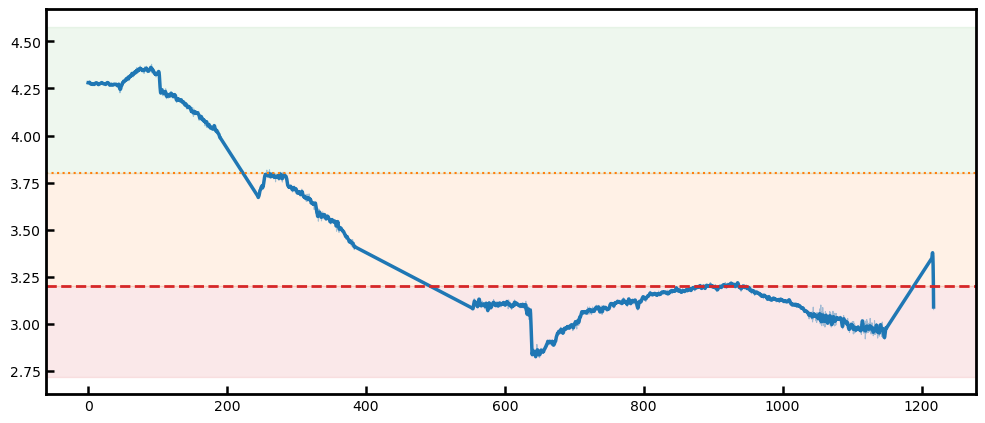

In [5]:

df = pd.read_csv(CSV_PATH)
df["Time-Date"] = pd.to_datetime(df["Time-Date"], utc=True)
df = df.sort_values("Time-Date").reset_index(drop=True)
df["elapsed_min"] = (df["Time-Date"] - df["Time-Date"].iloc[0]).dt.total_seconds() / 60.0

sat_thresh = 1e15
df["MQ137_saturated"] = (df["MQ137-NH3"] > sat_thresh).astype(int)

df["time_gap_s"]   = df["Time-Date"].diff().dt.total_seconds().fillna(0)
df["gap_boundary"] = (df["time_gap_s"] > 60).astype(int)

t_uniform = np.arange(df["elapsed_min"].min(), df["elapsed_min"].max(), 21 / 60.0)

interp_cols = ["Food_Temp", "Food_Humid", "MQ135-AirQuality",
               "MQ136-H2S", "Amb_Temp", "Amb_Humid", "PH", "MQ137_saturated"]
df_uni = pd.DataFrame({"elapsed_min": t_uniform})
for col in interp_cols:
    f = interp1d(df["elapsed_min"], df[col],
                 kind="linear", bounds_error=False, fill_value="extrapolate")
    df_uni[col] = f(t_uniform)

def iqr_clip(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(q1 - factor * iqr, q3 + factor * iqr)

for col in ["MQ135-AirQuality", "MQ136-H2S"]:
    df_uni[col] = iqr_clip(df_uni[col])

df_uni["log_MQ135"] = np.log1p(df_uni["MQ135-AirQuality"])
df_uni["log_MQ136"] = np.log1p(df_uni["MQ136-H2S"])

sg_cols = ["log_MQ135", "log_MQ136", "PH", "Amb_Humid", "Food_Temp"]
for col in sg_cols:
    df_uni[col + "_sg"] = savgol_filter(df_uni[col], window_length=11, polyorder=3)

dt = 21 / 60.0
diff_sources = {
    "pH"      : "PH_sg",
    "logMQ135": "log_MQ135_sg",
    "logMQ136": "log_MQ136_sg",
    "AmbHumid": "Amb_Humid_sg",
    "FoodTemp": "Food_Temp_sg",
}
for name, col in diff_sources.items():
    df_uni[f"d1_{name}"] = df_uni[col].diff() / dt
    df_uni[f"d2_{name}"] = df_uni[f"d1_{name}"].diff() / dt

df_uni["spoilage_index"] = (
    -df_uni["d1_pH"]
    + df_uni["d1_logMQ135"].clip(0)
    + df_uni["d1_logMQ136"].clip(0)
    + df_uni["d1_AmbHumid"].clip(0)
)

BASE_FEATURES = [
    "PH_sg", "log_MQ135_sg", "log_MQ136_sg",
    "Amb_Humid_sg", "Food_Temp_sg", "MQ137_saturated",
    "d1_pH", "d2_pH",
    "d1_logMQ135", "d1_logMQ136",
    "d1_AmbHumid", "d2_AmbHumid",
    "spoilage_index",
    "elapsed_min",
]

def build_features(data, lag_steps=(1, 5, 15), roll_window=20):
    feat     = data[BASE_FEATURES].copy()
    lag_cols = ["PH_sg", "d1_pH", "d2_pH",
                "log_MQ135_sg", "log_MQ136_sg", "spoilage_index"]
    for col in lag_cols:
        for k in lag_steps:
            feat[f"{col}_lag{k}"] = data[col].shift(k)
    roll_cols = ["PH_sg", "d1_pH", "spoilage_index", "Amb_Humid_sg"]
    for col in roll_cols:
        feat[f"{col}_rmean"] = data[col].rolling(roll_window, min_periods=1).mean()
        feat[f"{col}_rstd"]  = data[col].rolling(roll_window, min_periods=1).std().fillna(0)
    return feat

feat_df = build_features(df_uni)

spoilage_time = df_uni.loc[df_uni["PH"] <= SPOILAGE_PH, "elapsed_min"].min()
df_uni["time_to_spoil"] = (spoilage_time - df_uni["elapsed_min"]).clip(lower=0)

def ph_class(ph):
    if ph > 3.8:   return "Fresh"
    elif ph > 3.2: return "Warning"
    else:          return "Spoiled"

df_uni["spoilage_class"] = df_uni["PH"].apply(ph_class)

train_mask   = df_uni["elapsed_min"] < spoilage_time
X_all        = feat_df.fillna(0)
y_all        = df_uni["time_to_spoil"]
X_train_full = X_all[train_mask].values
y_train_full = y_all[train_mask].values
X_post       = X_all[~train_mask].values
y_post       = y_all[~train_mask].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_full)

GENE_BOUNDS = [
    (0, 2), (0.1, 10.0), (1e-4, 1.0),
    (0.1, 500.0), (0.01, 5.0), (1e-4, 1.0),
    (1, 20), (5, 40), (7, 21),
]

def decode_chromosome(chrom):
    kernel_idx = int(round(np.clip(chrom[0], 0, 2)))
    length_sc  = float(np.clip(chrom[1], 0.1, 10.0))
    noise      = float(np.clip(chrom[2], 1e-4, 1.0))
    svr_C      = float(np.clip(chrom[3], 0.1, 500.0))
    svr_eps    = float(np.clip(chrom[4], 0.01, 5.0))
    svr_gamma  = float(np.clip(chrom[5], 1e-4, 1.0))
    lag_k      = int(round(np.clip(chrom[6], 1, 20)))
    roll_win   = int(round(np.clip(chrom[7], 5, 40)))
    sg_win_raw = int(round(np.clip(chrom[8], 7, 21)))
    sg_win     = sg_win_raw if sg_win_raw % 2 == 1 else sg_win_raw + 1
    return kernel_idx, length_sc, noise, svr_C, svr_eps, svr_gamma, lag_k, roll_win, sg_win

def build_kernel(kernel_idx, length_sc):
    if kernel_idx == 0:
        return Matern(length_scale=length_sc, nu=1.5) + WhiteKernel()
    elif kernel_idx == 1:
        return Matern(length_scale=length_sc, nu=2.5) + WhiteKernel()
    else:
        return RBF(length_scale=length_sc) + WhiteKernel()

def fitness(chrom):
    try:
        (kernel_idx, length_sc, noise, svr_C, svr_eps,
         svr_gamma, lag_k, roll_win, sg_win) = decode_chromosome(chrom)
        lags = (1, lag_k, lag_k * 3)
        feat = build_features(df_uni, lag_steps=lags, roll_window=roll_win)
        X    = feat[train_mask].fillna(0).values
        y    = y_train_full
        sc   = StandardScaler()
        tscv = TimeSeriesSplit(n_splits=TSCV_SPLITS)
        gpr_rmses, svr_rmses = [], []
        for tr_idx, val_idx in tscv.split(X):
            X_tr, X_val = X[tr_idx], X[val_idx]
            y_tr, y_val = y[tr_idx], y[val_idx]
            X_tr_s  = sc.fit_transform(X_tr)
            X_val_s = sc.transform(X_val)
            n_gpr = min(300, len(X_tr_s))
            idx   = np.random.choice(len(X_tr_s), n_gpr, replace=False)
            kernel = build_kernel(kernel_idx, length_sc)
            gpr = GaussianProcessRegressor(
                kernel=kernel, alpha=noise,
                n_restarts_optimizer=1, random_state=RANDOM_SEED)
            gpr.fit(X_tr_s[idx], y_tr[idx])
            gpr_rmses.append(np.sqrt(mean_squared_error(y_val, gpr.predict(X_val_s))))
            svr = SVR(kernel="rbf", C=svr_C, epsilon=svr_eps, gamma=svr_gamma)
            svr.fit(X_tr_s, y_tr)
            svr_rmses.append(np.sqrt(mean_squared_error(y_val, svr.predict(X_val_s))))
        return 1.0 / (0.5 * np.mean(gpr_rmses) + 0.5 * np.mean(svr_rmses) + 1e-6)
    except Exception:
        return 0.0

def init_population(pop_size):
    return [np.array([np.random.uniform(lo, hi) for lo, hi in GENE_BOUNDS])
            for _ in range(pop_size)]

def tournament_select(pop, scores, k=3):
    idx  = np.random.choice(len(pop), k, replace=False)
    best = idx[np.argmax([scores[i] for i in idx])]
    return pop[best].copy()

def crossover(p1, p2):
    if np.random.rand() < GA_CROSSOVER_RATE:
        pt = np.random.randint(1, len(p1))
        return np.concatenate([p1[:pt], p2[pt:]]), np.concatenate([p2[:pt], p1[pt:]])
    return p1.copy(), p2.copy()

def mutate(chrom):
    for i, (lo, hi) in enumerate(GENE_BOUNDS):
        if np.random.rand() < GA_MUTATION_RATE:
            chrom[i] = np.clip(chrom[i] + np.random.normal(0, (hi - lo) * 0.1), lo, hi)
    return chrom

population       = init_population(GA_POP_SIZE)
best_score       = -np.inf
best_chrom       = population[0]
ga_history       = []
ga_pop_diversity = []

for gen in range(GA_GENERATIONS):
    scores = [fitness(c) for c in population]
    gen_best_idx = np.argmax(scores)
    if scores[gen_best_idx] > best_score:
        best_score = scores[gen_best_idx]
        best_chrom = population[gen_best_idx].copy()
    ga_history.append(1.0 / (best_score + 1e-9))
    ga_pop_diversity.append(np.std([1.0 / (s + 1e-9) for s in scores]))
    new_pop = [best_chrom.copy()]
    while len(new_pop) < GA_POP_SIZE:
        p1 = tournament_select(population, scores)
        p2 = tournament_select(population, scores)
        c1, c2 = crossover(p1, p2)
        new_pop.extend([mutate(c1), mutate(c2)])
    population = new_pop[:GA_POP_SIZE]

(best_kernel_idx, best_length_sc, best_noise,
 best_svr_C, best_svr_eps, best_svr_gamma,
 best_lag_k, best_roll_win, best_sg_win) = decode_chromosome(best_chrom)

best_lags  = (1, best_lag_k, best_lag_k * 3)
feat_final = build_features(df_uni, lag_steps=best_lags, roll_window=best_roll_win)
X_final_all = feat_final.fillna(0).values
X_train_f   = X_final_all[train_mask]
y_train_f   = y_train_full
scaler_f    = StandardScaler()
X_train_fs  = scaler_f.fit_transform(X_train_f)

n_gpr_train  = min(400, len(X_train_fs))
idx_gpr      = np.linspace(0, len(X_train_fs) - 1, n_gpr_train, dtype=int)
kernel_final = build_kernel(best_kernel_idx, best_length_sc)
gpr_final    = GaussianProcessRegressor(
    kernel=kernel_final, alpha=best_noise,
    n_restarts_optimizer=3, random_state=RANDOM_SEED)
gpr_final.fit(X_train_fs[idx_gpr], y_train_f[idx_gpr])

svr_final = SVR(kernel="rbf", C=best_svr_C, epsilon=best_svr_eps, gamma=best_svr_gamma)
svr_final.fit(X_train_fs, y_train_f)

tscv         = TimeSeriesSplit(n_splits=TSCV_SPLITS)
meta_X, meta_y = [], []
for tr, val in tscv.split(X_train_f):
    Xtr = scaler_f.fit_transform(X_train_f[tr])
    Xvl = scaler_f.transform(X_train_f[val])
    ytr, yvl = y_train_f[tr], y_train_f[val]
    n_sub = min(300, len(Xtr))
    idx_s = np.random.choice(len(Xtr), n_sub, replace=False)
    g = GaussianProcessRegressor(kernel=kernel_final, alpha=best_noise,
                                 n_restarts_optimizer=1, random_state=RANDOM_SEED)
    g.fit(Xtr[idx_s], ytr[idx_s])
    gp, gs = g.predict(Xvl, return_std=True)
    s = SVR(kernel="rbf", C=best_svr_C, epsilon=best_svr_eps, gamma=best_svr_gamma)
    s.fit(Xtr, ytr)
    meta_X.append(np.column_stack([gp, s.predict(Xvl), gs]))
    meta_y.append(yvl)

meta_X       = np.vstack(meta_X)
meta_y       = np.concatenate(meta_y)
meta_learner = Ridge(alpha=1.0)
meta_learner.fit(meta_X, meta_y)

scaler_f.fit(X_train_f)
X_train_fs = scaler_f.transform(X_train_f)

split_pt        = int(0.8 * len(X_train_f))
X_eval          = X_train_f[split_pt:]
y_eval          = y_train_f[split_pt:]
X_eval_s        = scaler_f.transform(X_eval)
gpr_pred_eval, gpr_std_eval = gpr_final.predict(X_eval_s, return_std=True)
svr_pred_eval               = svr_final.predict(X_eval_s)
meta_pred_eval              = meta_learner.predict(
    np.column_stack([gpr_pred_eval, svr_pred_eval, gpr_std_eval])).clip(0)

def metrics(y_true, y_pred):
    return dict(
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred))),
        mae  = float(mean_absolute_error(y_true, y_pred)),
        r2   = float(r2_score(y_true, y_pred)),
    )

m_gpr = metrics(y_eval, gpr_pred_eval.clip(0))
m_svr = metrics(y_eval, svr_pred_eval.clip(0))
m_ens = metrics(y_eval, meta_pred_eval)

print(f"Spoilage onset: {spoilage_time:.1f} min ({spoilage_time/60:.2f} hrs)")
print(f"GPR      RMSE={m_gpr['rmse']:.2f} min  MAE={m_gpr['mae']:.2f} min  R²={m_gpr['r2']:.4f}")
print(f"SVR      RMSE={m_svr['rmse']:.2f} min  MAE={m_svr['mae']:.2f} min  R²={m_svr['r2']:.4f}")
print(f"Ensemble RMSE={m_ens['rmse']:.2f} min  MAE={m_ens['mae']:.2f} min  R²={m_ens['r2']:.4f}")

def predict_spoilage(elapsed_min_query):
    row_idx       = (df_uni["elapsed_min"] - elapsed_min_query).abs().idxmin()
    x_raw         = feat_final.fillna(0).iloc[row_idx].values.reshape(1, -1)
    x_sc          = scaler_f.transform(x_raw)
    gpr_mu, gpr_sigma = gpr_final.predict(x_sc, return_std=True)
    svr_mu        = svr_final.predict(x_sc)
    ens_mu        = meta_learner.predict(
        np.column_stack([gpr_mu, svr_mu, gpr_sigma])).clip(0)
    ph_now        = df_uni.loc[row_idx, "PH"]
    class_now     = df_uni.loc[row_idx, "spoilage_class"]
    ci_lo         = max(0, ens_mu[0] - 2 * gpr_sigma[0])
    ci_hi         = ens_mu[0] + 2 * gpr_sigma[0]
    alert         = ens_mu[0] < ALERT_MINUTES or class_now == "Spoiled"
    return dict(
        elapsed_min  = elapsed_min_query,
        current_ph   = float(ph_now),
        cls          = class_now,
        gpr_pred_min = float(max(0, gpr_mu[0])),
        svr_pred_min = float(max(0, svr_mu[0])),
        ensemble_min = float(ens_mu[0]),
        ci_lo        = float(ci_lo),
        ci_hi        = float(ci_hi),
        gpr_sigma    = float(gpr_sigma[0]),
        alert        = bool(alert),
    )

t_vals  = df_uni["elapsed_min"][train_mask].values
X_all_s = scaler_f.transform(X_train_f)
gpr_all, gpr_sig_all = gpr_final.predict(X_all_s, return_std=True)
svr_all              = svr_final.predict(X_all_s)
ens_all              = meta_learner.predict(
    np.column_stack([gpr_all, svr_all, gpr_sig_all])).clip(0)

t_all = df_uni["elapsed_min"].values

fig, ax = plt.subplots(figsize=(12, 5))
ax.axhspan(3.8, df_uni["PH"].max() + 0.2, alpha=0.08, color=ZONE_COLORS["fresh"],   label="Fresh zone")
ax.axhspan(3.2, 3.8,                       alpha=0.10, color=ZONE_COLORS["warning"], label="Warning zone")
ax.axhspan(df_uni["PH"].min() - 0.1, 3.2,  alpha=0.10, color=ZONE_COLORS["spoiled"],label="Spoiled zone")
ax.plot(t_all, df_uni["PH"],    color=C["ph"], lw=0.8, alpha=0.4, label="Raw pH")
ax.plot(t_all, df_uni["PH_sg"], color=C["ph"], lw=2.5, label="Smoothed pH (SG)")
ax.axhline(SPOILAGE_PH,  color=C["alert"],   ls="--", lw=2.0, label=f"Spoilage threshold (pH {SPOILAGE_PH})")
ax.axhline(3.8,           color=C["warning"], ls=":",  lw=1.5, label="Warning threshold (pH 3.8)")
ax.axvline(spoilage_time, color=C["spoiled"], ls="-.", lw=2.0, label=f"Spoilage onset ({spoilage_time/60:.1f} h)")
ax.set_xlabel("Elapsed Time (min)",  fontsize=16, fontweight='bold')
ax.set_ylabel("pH",                   fontsize=16, fontweight='bold')
ax.set_title("pH Trajectory & Spoilage Zone Classification", fontsize=18, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9, ncol=2)
style_ax(ax, 14)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "01_ph_trajectory.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
panels = [
    (axes[0, 0], "log_MQ135",  "log_MQ135_sg", C["mq135"],    "Log MQ135 (Air Quality)"),
    (axes[0, 1], "log_MQ136",  "log_MQ136_sg", C["mq136"],    "Log MQ136 (H₂S)"),
    (axes[1, 0], "Food_Temp",  "Food_Temp_sg", C["food_temp"],"Food Temperature (°C)"),
    (axes[1, 1], "Amb_Humid",  "Amb_Humid_sg", C["humidity"], "Ambient Humidity (%)"),
]
for ax, raw_col, sg_col, col, title in panels:
    ax.plot(t_all, df_uni[raw_col], color=col, lw=0.6, alpha=0.35)
    ax.plot(t_all, df_uni[sg_col],  color=col, lw=2.2, label="Smoothed")
    ax.axvline(spoilage_time, color=C["alert"], ls="--", lw=1.5, alpha=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Value", fontsize=12, fontweight='bold')
    style_ax(ax, 12)
for ax in axes[1]:
    ax.set_xlabel("Elapsed Time (min)", fontsize=12, fontweight='bold')
fig.suptitle("Sensor Signal Overview  (dashed = spoilage onset)", fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "02_sensor_dashboard.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
ax = axes[0]
ax.plot(t_all, df_uni["spoilage_index"].fillna(0), color=C["spoilage"], lw=2.0)
ax.axvline(spoilage_time, color=C["alert"], ls="--", lw=1.8, label="Spoilage onset")
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_ylabel("Spoilage Index", fontsize=13, fontweight='bold')
ax.set_title("Composite Spoilage Index", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
style_ax(ax, 12)
ax = axes[1]
ax.plot(t_all, df_uni["d1_pH"].fillna(0),       color=C["ph"],    lw=2.0, label="d(pH)/dt")
ax.plot(t_all, df_uni["d1_logMQ135"].fillna(0),  color=C["mq135"], lw=1.6, alpha=0.8, label="d(logMQ135)/dt")
ax.plot(t_all, df_uni["d1_logMQ136"].fillna(0),  color=C["mq136"], lw=1.6, alpha=0.8, label="d(logMQ136)/dt")
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.axvline(spoilage_time, color=C["alert"], ls="--", lw=1.8)
ax.set_ylabel("1st Derivative", fontsize=13, fontweight='bold')
ax.set_title("First-Order Rate of Change", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, ncol=3)
style_ax(ax, 12)
ax = axes[2]
ax.plot(t_all, df_uni["d2_pH"].fillna(0), color=C["ph"], lw=2.0, label="d²(pH)/dt²")
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.axvline(spoilage_time, color=C["alert"], ls="--", lw=1.8, label="Spoilage onset")
ax.set_xlabel("Elapsed Time (min)", fontsize=13, fontweight='bold')
ax.set_ylabel("2nd Derivative",     fontsize=13, fontweight='bold')
ax.set_title("Second-Order Rate of Change (pH Curvature)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
style_ax(ax, 12)
fig.suptitle("Spoilage Dynamics — Derivatives & Composite Index", fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "03_spoilage_derivatives.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

gens = np.arange(1, len(ga_history) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(gens,
                np.array(ga_history) - np.array(ga_pop_diversity),
                np.array(ga_history) + np.array(ga_pop_diversity),
                alpha=0.20, color=C["ga_hist"], label="Population spread (±1 std)")
ax.plot(gens, ga_history, color=C["ga_hist"], lw=2.8, marker='o', markersize=5, label="Best RMSE (min)")
ax.set_xlabel("Generation",      fontsize=16, fontweight='bold')
ax.set_ylabel("Best RMSE (min)", fontsize=16, fontweight='bold')
ax.set_title("Genetic Algorithm Convergence", fontsize=18, fontweight='bold')
ax.legend(fontsize=13)
style_ax(ax, 14)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "04_ga_convergence.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(t_vals, y_train_f,        color=C["true_val"], lw=2.5, label="True time-to-spoil", zorder=5)
ax.plot(t_vals, gpr_all.clip(0),  color=C["gpr"],      lw=1.8, ls="--", alpha=0.9, label="GPR")
ax.plot(t_vals, svr_all.clip(0),  color=C["svr"],      lw=1.8, ls=":",  alpha=0.9, label="SVR")
ax.plot(t_vals, ens_all,          color=C["ensemble"], lw=2.2, alpha=0.9, label="Ensemble")
ax.fill_between(t_vals,
                (ens_all - 2 * gpr_sig_all).clip(0),
                ens_all + 2 * gpr_sig_all,
                alpha=0.15, color=C["ci"], label="Ensemble 95% CI")
ax.axhline(ALERT_MINUTES, color=C["alert"], ls="--", lw=1.8, label=f"Alert threshold ({ALERT_MINUTES} min)")
ax.set_xlabel("Elapsed Time (min)",       fontsize=16, fontweight='bold')
ax.set_ylabel("Time to Spoilage (min)",   fontsize=16, fontweight='bold')
ax.set_title("Predicted Time-to-Spoilage vs Ground Truth", fontsize=18, fontweight='bold')
ax.legend(fontsize=11, ncol=3, framealpha=0.9)
style_ax(ax, 14)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "05_time_to_spoil_timeline.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

models_scatter = [
    ("GPR",      gpr_pred_eval.clip(0), m_gpr),
    ("SVR",      svr_pred_eval.clip(0), m_svr),
    ("Ensemble", meta_pred_eval,        m_ens),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (model_name, y_pred, m) in zip(axes, models_scatter):
    lim_min = min(y_eval.min(), y_pred.min()) * 0.97
    lim_max = max(y_eval.max(), y_pred.max()) * 1.03
    xy  = np.vstack([y_eval, y_pred])
    kde = gaussian_kde(xy)(xy)
    sc = ax.scatter(y_eval, y_pred, c=kde, cmap="jet",
                    norm=LogNorm(vmin=kde.min() + 1e-12, vmax=kde.max()),
                    s=18, alpha=0.85, edgecolors='none', rasterized=True)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color='k', lw=2.2, ls='--', label="1 : 1 line")
    txt = (f"RMSE = {m['rmse']:.2f} min\n"
           f"MAE  = {m['mae']:.2f} min\n"
           f"R²   = {m['r2']:.4f}")
    ax.text(0.03, 0.97, txt, transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))
    ax.set_xlabel("Actual Time-to-Spoil (min)",    fontweight='bold', fontsize=16)
    ax.set_ylabel("Predicted Time-to-Spoil (min)", fontweight='bold', fontsize=16)
    ax.set_title(f"{model_name}  —  Density (Log) Plot", fontweight='bold', fontsize=16)
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.legend(fontsize=12, framealpha=0.9)
    for spine in ax.spines.values():
        spine.set_linewidth(3.0)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')
        tick.set_fontsize(13)
    cb = fig.colorbar(sc, ax=ax, pad=0.02, aspect=28)
    cb.set_label('Density (Log)', fontweight='bold', fontsize=14)
    cb.ax.tick_params(labelsize=12, width=2.0, length=5)
    cb.outline.set_linewidth(2.0)
    for t in cb.ax.get_yticklabels():
        t.set_fontweight('bold')
fig.suptitle("Actual vs Predicted Time-to-Spoilage — All Models", fontsize=22, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "06_density_actual_vs_predicted.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

from scipy import stats as scipy_stats
residuals = meta_pred_eval - y_eval
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ax = axes[0]
ax.hist(residuals, bins=30, color=C["ensemble"], edgecolor='white', lw=0.5, density=True, alpha=0.85)
xr = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(xr, scipy_stats.norm.pdf(xr, residuals.mean(), residuals.std()), color='k', lw=2.2, label="Normal fit")
ax.axvline(0, color=C["alert"], ls='--', lw=1.8)
ax.set_xlabel("Residual (min)", fontsize=14, fontweight='bold')
ax.set_ylabel("Density",        fontsize=14, fontweight='bold')
ax.set_title("Residual Histogram", fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
style_ax(ax, 12)
ax = axes[1]
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr, s=15, color=C["ensemble"], alpha=0.7, label="Residuals")
ax.plot(osm, slope * np.array(osm) + intercept, color='k', lw=2.2, label="Normal ref.")
ax.set_xlabel("Theoretical Quantiles", fontsize=14, fontweight='bold')
ax.set_ylabel("Sample Quantiles",       fontsize=14, fontweight='bold')
ax.set_title("Q-Q Plot (Normality Check)", fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
style_ax(ax, 12)
ax = axes[2]
ax.scatter(y_eval, residuals, s=20, color=C["ensemble"], alpha=0.6)
ax.axhline(0, color=C["alert"], ls='--', lw=2.0)
ax.set_xlabel("Actual Time-to-Spoil (min)", fontsize=14, fontweight='bold')
ax.set_ylabel("Residual (min)",             fontsize=14, fontweight='bold')
ax.set_title("Residuals vs Actual Values",  fontsize=15, fontweight='bold')
style_ax(ax, 12)
fig.suptitle("Ensemble Residual Analysis", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "07_residual_analysis.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

t_eval   = t_vals[split_pt:]
sort_idx = np.argsort(t_eval)
t_s      = t_eval[sort_idx]
y_s      = y_eval[sort_idx]
g_s      = gpr_pred_eval[sort_idx]
sig_s    = gpr_std_eval[sort_idx]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_s, y_s,          color=C["true_val"], lw=2.5, label="True", zorder=5)
ax.plot(t_s, g_s.clip(0),  color=C["gpr"],      lw=2.0, ls='--', label="GPR mean")
ax.fill_between(t_s, (g_s - sig_s).clip(0), g_s + sig_s,         alpha=0.20, color=C["gpr"], label="GPR ±1σ")
ax.fill_between(t_s, (g_s - 2 * sig_s).clip(0), g_s + 2 * sig_s, alpha=0.10, color=C["gpr"], label="GPR ±2σ (95%)")
ax.axhline(ALERT_MINUTES, color=C["alert"], ls=':', lw=1.8, label=f"Alert ({ALERT_MINUTES} min)")
ax.set_xlabel("Elapsed Time (min)",     fontsize=16, fontweight='bold')
ax.set_ylabel("Time to Spoilage (min)", fontsize=16, fontweight='bold')
ax.set_title("GPR Uncertainty Band on Evaluation Split", fontsize=18, fontweight='bold')
ax.legend(fontsize=12, ncol=2, framealpha=0.9)
style_ax(ax, 14)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "08_gpr_uncertainty.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

models_lbl = ["GPR", "SVR", "Ensemble"]
rmse_vals  = [m_gpr["rmse"], m_svr["rmse"], m_ens["rmse"]]
mae_vals   = [m_gpr["mae"],  m_svr["mae"],  m_ens["mae"]]
r2_vals    = [m_gpr["r2"],   m_svr["r2"],   m_ens["r2"]]
bar_colors = [C["gpr"], C["svr"], C["ensemble"]]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, vals, ylabel, title in [
    (axes[0], rmse_vals, "RMSE (min)", "Root Mean Squared Error"),
    (axes[1], mae_vals,  "MAE (min)",  "Mean Absolute Error"),
    (axes[2], r2_vals,   "R² Score",   "Coefficient of Determination"),
]:
    bars = ax.bar(models_lbl, vals, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(vals),
                f"{val:.3f}", ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_title(title,   fontsize=15, fontweight='bold')
    style_ax(ax, 13)
fig.suptitle("Model Performance Comparison", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "09_model_comparison.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

query_times = [t for t in [60, 150, 250, 350, 450, 550]
               if t <= df_uni["elapsed_min"].max()]
results = [predict_spoilage(t) for t in query_times]
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
ax = axes[0]
ax.plot(t_all, df_uni["PH_sg"], color=C["ph"], lw=2.5, label="pH (smoothed)")
ax.axhline(SPOILAGE_PH, color=C["alert"],   ls='--', lw=1.8)
ax.axhline(3.8,          color=C["warning"], ls=':',  lw=1.5)
for r in results:
    col = C["alert"] if r["alert"] else C["safe"]
    ax.axvline(r["elapsed_min"], color=col, lw=1.2, alpha=0.5)
    ax.scatter(r["elapsed_min"], r["current_ph"], s=90, color=col, zorder=6, edgecolors='k', linewidths=0.7)
ax.set_ylabel("pH", fontsize=14, fontweight='bold')
ax.set_title("pH Trajectory with Real-Time Query Points", fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
style_ax(ax, 12)
ax = axes[1]
ens_vals = [r["ensemble_min"] for r in results]
ci_lo    = [r["ci_lo"]        for r in results]
ci_hi    = [r["ci_hi"]        for r in results]
colors   = [C["alert"] if r["alert"] else C["safe"] for r in results]
ax.bar(query_times, ens_vals, width=15, color=colors, alpha=0.75, edgecolor='white', linewidth=0.8, label="Ensemble prediction")
for qt, lo, hi in zip(query_times, ci_lo, ci_hi):
    ax.plot([qt, qt], [lo, hi], color='k', lw=2.2)
    ax.plot([qt - 5, qt + 5], [lo, lo], color='k', lw=2.0)
    ax.plot([qt - 5, qt + 5], [hi, hi], color='k', lw=2.0)
ax.axhline(ALERT_MINUTES, color=C["alert"], ls='--', lw=2.0, label=f"Alert threshold ({ALERT_MINUTES} min)")
ax.set_xlabel("Elapsed Time (min)",            fontsize=14, fontweight='bold')
ax.set_ylabel("Predicted Time-to-Spoil (min)", fontsize=14, fontweight='bold')
ax.set_title("Ensemble Predictions & 95% CI at Query Points", fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
style_ax(ax, 12)
for r, qt in zip(results, query_times):
    status = "⚠ ALERT" if r["alert"] else "✓ Safe"
    ax.text(qt, r["ensemble_min"] + 3, status, ha='center', fontsize=9, fontweight='bold',
            color=C["alert"] if r["alert"] else C["safe"])
fig.suptitle("Real-Time Spoilage Alert Dashboard", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "10_alert_dashboard.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

import matplotlib.colors as mcolors
heat_cols    = ["PH_sg", "log_MQ135_sg", "log_MQ136_sg",
                "Amb_Humid_sg", "Food_Temp_sg",
                "d1_pH", "d2_pH", "d1_logMQ135", "d1_logMQ136", "spoilage_index"]
short_labels = ["pH", "MQ135", "MQ136", "AmbHumid", "FoodTemp",
                "d₁pH", "d₂pH", "d₁MQ135", "d₁MQ136", "SpoilIdx"]
corr = df_uni[heat_cols].dropna().corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect='auto')
n = len(heat_cols)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12, fontweight='bold')
ax.set_yticklabels(short_labels, fontsize=12, fontweight='bold')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Pearson r", fontsize=14, fontweight='bold')
for t in cb.ax.get_yticklabels():
    t.set_fontweight('bold'); t.set_fontsize(12)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
ax.set_title("Feature Correlation Heatmap", fontsize=18, fontweight='bold', pad=14)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "11_feature_correlation.png"), dpi=300, bbox_inches='tight')
plt.close(fig)

class_counts = df_uni["spoilage_class"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 2]})
ax = axes[0]
pie_cols = [ZONE_COLORS.get(c.lower(), '#888') for c in class_counts.index]
wedges, texts, autotexts = ax.pie(
    class_counts.values, labels=class_counts.index, colors=pie_cols,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(linewidth=2, edgecolor='white'),
    textprops=dict(fontsize=14, fontweight='bold'),
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold')
ax.set_title("Spoilage Class Distribution", fontsize=15, fontweight='bold')
ax = axes[1]
class_map = {"Fresh": 0, "Warning": 1, "Spoiled": 2}
c_vals = df_uni["spoilage_class"].map(class_map).values.reshape(1, -1)
cmap   = matplotlib.colors.ListedColormap(
    [ZONE_COLORS["fresh"], ZONE_COLORS["warning"], ZONE_COLORS["spoiled"]])
ax.imshow(c_vals, aspect='auto',
          extent=[t_all.min(), t_all.max(), 0, 1],
          cmap=cmap, vmin=0, vmax=2)
ax.set_yticks([])
ax.set_xlabel("Elapsed Time (min)", fontsize=14, fontweight='bold')
ax.set_title("Spoilage Class Timeline",  fontsize=15, fontweight='bold')
for lbl, col, val in [("Fresh", ZONE_COLORS["fresh"], 0),
                       ("Warning", ZONE_COLORS["warning"], 1),
                       ("Spoiled", ZONE_COLORS["spoiled"], 2)]:
    ax.scatter([], [], color=col, s=80, label=lbl)
ax.legend(fontsize=12, loc='upper right')
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
for lbl in ax.get_xticklabels():
    lbl.set_fontweight('bold'); lbl.set_fontsize(12)
fig.suptitle("Meat Freshness Classification", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "12_spoilage_class.png"), dpi=300, bbox_inches='tight')
plt.close(fig)